<a href="https://colab.research.google.com/github/harmanbajwa2954/Stroke_Prediction/blob/main/Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [87]:
df = pd.read_csv('https://raw.githubusercontent.com/harmanbajwa2954/datasets/refs/heads/main/healthcare-dataset-stroke-data.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


Preprocessing

In [88]:
#dropping id
df = df.drop(columns=['id'])

In [90]:
print("--- Initial Missing Values ---")
print(df.isnull().sum())

--- Initial Missing Values ---
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [91]:
# converting bmi values to numeric values and fuilling missing values
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [92]:
#again checking for missing values
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [93]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


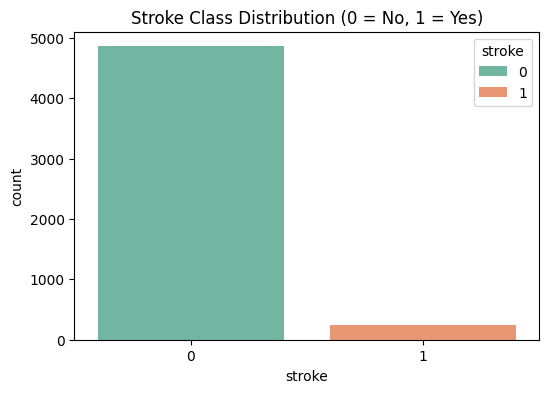

In [94]:
# checking for class imbalance in the target
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df,hue='stroke', palette='Set2')
plt.title('Stroke Class Distribution (0 = No, 1 = Yes)')
plt.show()

In [95]:
#applying One hot encoding on all categorical values
df_encoded = pd.get_dummies(df, drop_first = True)

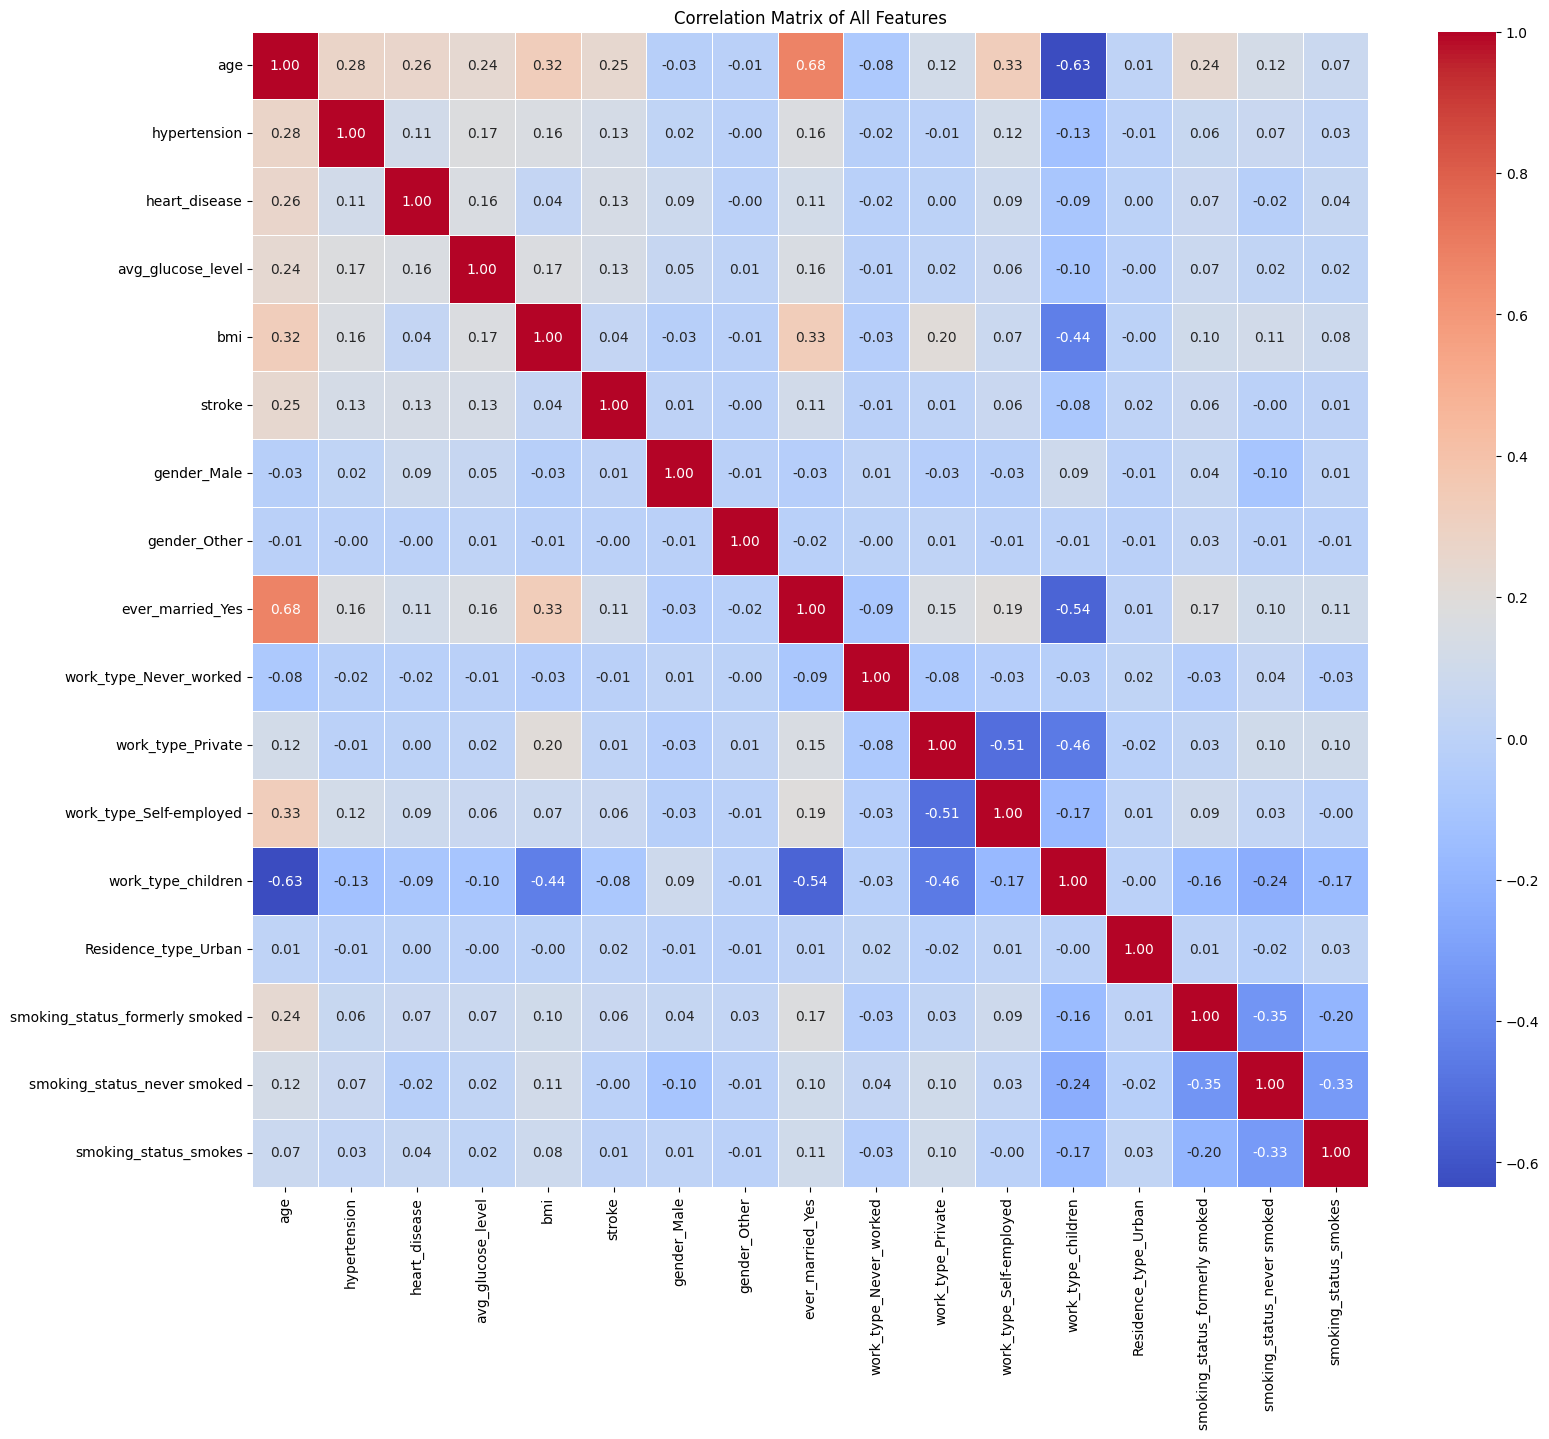

In [96]:
plt.figure(figsize=(18, 15))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

In [97]:
# separating features and target
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

In [37]:
X

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,False,False,True,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,80.0,1,0,83.75,28.1,False,False,True,False,True,False,False,True,False,True,False
5106,81.0,0,0,125.20,40.0,False,False,True,False,False,True,False,True,False,True,False
5107,35.0,0,0,82.99,30.6,False,False,True,False,False,True,False,False,False,True,False
5108,51.0,0,0,166.29,25.6,True,False,True,False,True,False,False,False,True,False,False


In [38]:
y

,stroke
0,1
1,1
2,1
3,1
4,1
...,...
5105,0
5106,0
5107,0
5108,0


In [39]:
# Test-Train Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state =42, stratify=y)

In [41]:
# standardizing numerical columns
num_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [42]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


--- Train Set Class Distribution AFTER SMOTE ---
stroke
0    3889
1    3889
Name: count, dtype: int64


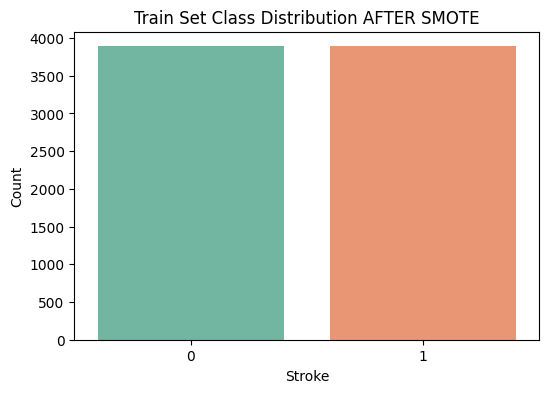

In [71]:
print(f"\n--- Train Set Class Distribution AFTER SMOTE ---")
print(y_train_smote.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote,hue=y_train_smote, palette='Set2',legend=False)
plt.title('Train Set Class Distribution AFTER SMOTE')
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.show()

### Model Fitting and Evaluation

using Random Forest Classifier

In [65]:
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight_value
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [66]:
#predicting on test data
y_pred = model.predict(X_test)

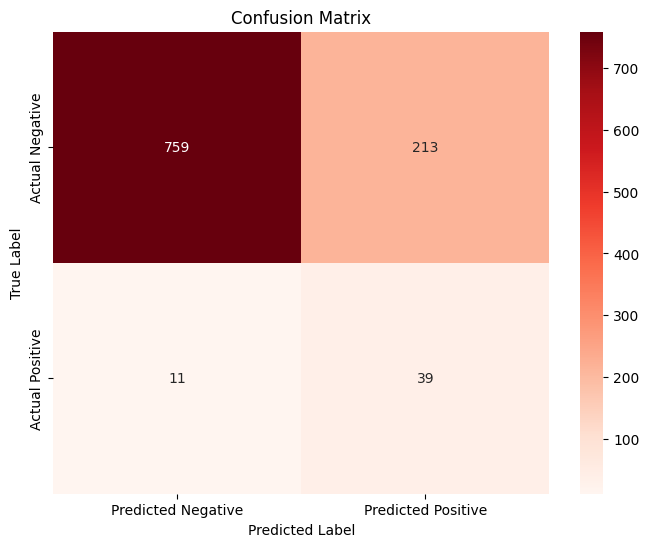

In [67]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [68]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.78      0.87       972
           1       0.15      0.78      0.26        50

    accuracy                           0.78      1022
   macro avg       0.57      0.78      0.56      1022
weighted avg       0.95      0.78      0.84      1022



### Saving the Model as Pickel file

In [73]:
import pickle as pkl

In [74]:
with open('xgboost_model.pkl', 'wb') as file:
    pkl.dump(model, file)

In [75]:
with open('xgboost_columns.pkl', 'wb') as file:
  pkl.dump(X_train_smote.columns, file)